In [20]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import pywt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [21]:
# Load the dataset

In [22]:
dataset_path = r"E:\project\Speech_Emotion_Recognition\dataset"

files = []
labels = []

# القاموس المعدل ليتناسب مع اختصارات CREMA-D الموجودة في ملفاتك
emotion_dict = {
    'NEU': 'neutral',
    'HAP': 'happy',
    'SAD': 'sad',
    'ANG': 'angry'
    
}

# استخدمنا os.walk لأنه يبحث في المجلد الرئيسي وأي مجلدات فرعية تلقائياً
for root, dirs, filenames in os.walk(dataset_path):
    for file in filenames:
        if file.endswith(".wav"):
            # الملفات عندك تستخدم الشرطة السفلية (_) وليس الشرطة العادية (-)
            parts = file.split("_")
            
            # التأكد من أن الملف يتبع التنسيق الصحيح (يحتوي على 3 أجزاء على الأقل)
            if len(parts) >= 3:
                emotion_code = parts[2]  # سيستخرج 'ANG', 'HAP', إلخ
                
                # التأكد من أن الكود موجود في القاموس
                if emotion_code in emotion_dict:
                    file_path = os.path.join(root, file)
                    files.append(file_path)
                    labels.append(emotion_dict[emotion_code])

print("Total Files found:", len(files))

# التأكد من وجود ملفات قبل الطباعة لتجنب الـ IndexError
if len(labels) > 0:
    print("Sample Label:", labels[0])
    print("Sample Path:", files[0])
else:
    print("No matching files found! Check if the emotion codes in filenames match the dictionary.")

Total Files found: 4900
Sample Label: angry
Sample Path: E:\project\Speech_Emotion_Recognition\dataset\1001_DFA_ANG_XX.wav


In [23]:
#Feature Extraction

In [114]:
def extract_mfcc(file_path):

    audio, sample_rate = librosa.load(file_path, duration=3)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    mfcc_mean = np.mean(mfcc.T, axis=0)

    return mfcc_mean

In [115]:
sample_features = extract_mfcc(files[0])

print(sample_features.shape)

(40,)


In [116]:
def extract_wavelet(file_path):

    audio, sample_rate = librosa.load(file_path, duration=3)

    coeffs = pywt.wavedec(audio, 'db1', level=3)

    wavelet_features = []

    for coeff in coeffs:

        wavelet_features.append(np.mean(coeff))

        wavelet_features.append(np.std(coeff))

    return np.array(wavelet_features)

In [117]:
wavelet_sample = extract_wavelet(files[0])

print(wavelet_sample.shape)

(8,)


In [118]:
def extract_features(file_path):

    mfcc_features = extract_mfcc(file_path)

    wavelet_features = extract_wavelet(file_path)

    combined = np.hstack((mfcc_features, wavelet_features))

    return combined

In [119]:
X = []

for file in files:

    features = extract_features(file)

    X.append(features)

X = np.array(X)

y = np.array(labels)

print(X.shape)

(4900, 48)


In [120]:
#Data Preprocessing


In [121]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [122]:
from sklearn.feature_selection import SelectKBest, f_classif

# اختيار أفضل 20 ميزة من الـ 48 الأصلية
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X_scaled, y)

# لمعرفة أي ميزات تم اختيارها
selected_indices = selector.get_support(indices=True)
print("Selected Feature Indices:", selected_indices)

# الآن استخدم X_selected في الـ Train/Test Split بدلاً من X_pca
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

Selected Feature Indices: [ 0  1  2  3  5  7  9 14 15 16 17 24 26 28 34 36 41 43 45 47]


In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [124]:
model = SVC(
    kernel='rbf',
    C=10,
    gamma=0.01
)

model.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [125]:
y_pred = model.predict(X_test)

In [126]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6591836734693878


In [127]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       angry       0.74      0.74      0.74       254
       happy       0.60      0.56      0.58       254
     neutral       0.55      0.58      0.57       218
         sad       0.73      0.75      0.74       254

    accuracy                           0.66       980
   macro avg       0.66      0.66      0.66       980
weighted avg       0.66      0.66      0.66       980



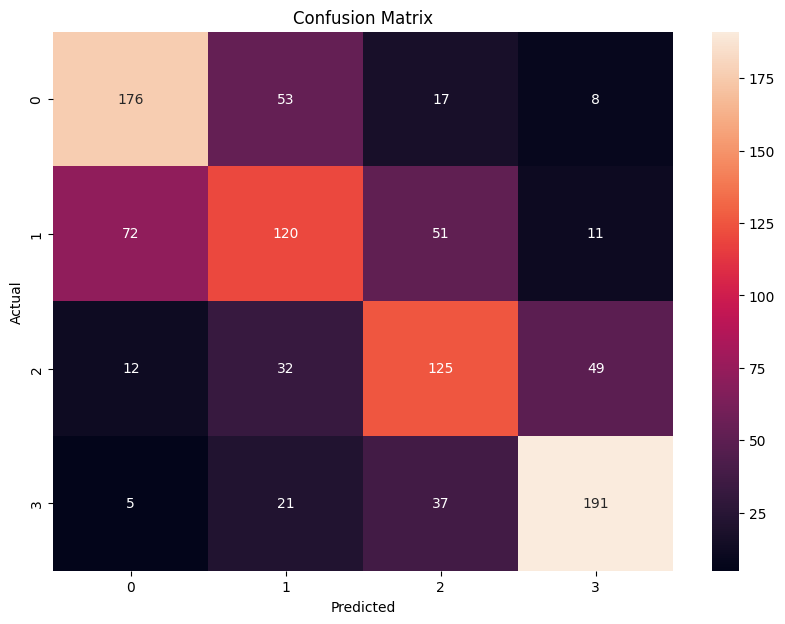

In [73]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [81]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly']
}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)
print(grid.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.5s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.5s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.5s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   1.1s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.9s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   1.2s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   1.3s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   3.5s
[CV] END .......................C=0.1, gamma=0.

Starting Model Comparison...
✅ SVM Accuracy: 67.45%
✅ Random Forest Accuracy: 65.71%
✅ Neural Network (MLP) Accuracy: 66.63%


C:\Users\saram\AppData\Local\Temp\ipykernel_8828\2317808843.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='magma')


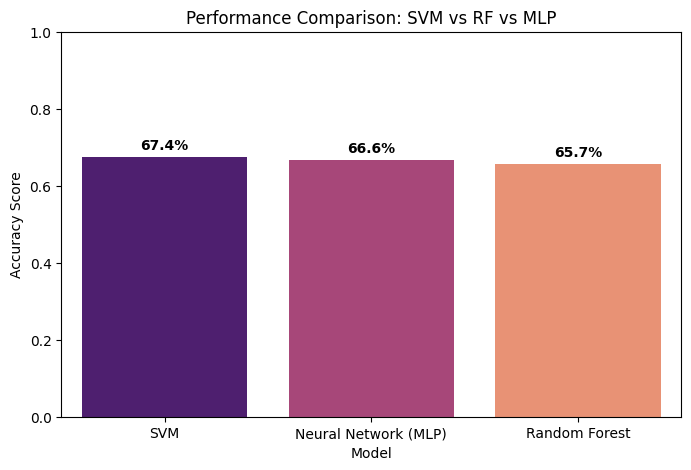

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تعريف الموديلات (بدون XGBoost)
models = {
    "SVM": SVC(kernel='rbf', C=10, gamma='scale'),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=1000, random_state=42)
}

results = {}

print("Starting Model Comparison...")

# 2. تدريب وتقييم كل موديل
for name, model in models.items():
    # تدريب الموديل
    model.fit(X_train, y_train)
    
    # التنبؤ وحساب الدقة
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    
    results[name] = acc
    print(f"✅ {name} Accuracy: {acc*100:.2f}%")

# 3. عرض النتائج في جدول
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

# 4. رسم المخطط البياني
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='magma')
plt.title('Performance Comparison: SVM vs RF vs MLP')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
for i, v in enumerate(results_df['Accuracy']):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')
plt.show()